In [ ]:
# Устанавливаем Pandas 3.0.2 (2 раза запустите)
!pip install --upgrade pip
!pip install pandas==3.0.2


In [ ]:
import pandas as pd
import numpy as np
import time
import os
import json

print(f"Pandas version: {pd.__version__}")

Pandas version: 3.0.2


## Генерируем банковский датасет
Создадим 50 000 записей о клиентах: имена, возраст (от 21 до 65), доход (от 20 000 до 500 000), кредитная нагрузка DTI (от 0 до 1), флаг дефолта (True/False) и дата заявки.



In [ ]:
# Фиксируем random seed для воспроизводимости
np.random.seed(42)

# Параметры датасета
N = 50000
names = ['Иван', 'Ольга', 'Дмитрий', 'Екатерина', 'Сергей', 'Анна', 'Алексей', 'Мария', 'Николай', 'Татьяна']

# Генерируем данные
df_original = pd.DataFrame({
    'client_id': range(1001, 1001 + N),                    # ID клиента
    'name': np.random.choice(names, N),                    # Имя
    'age': np.random.randint(21, 66, N),                   # Возраст
    'income': np.random.randint(20000, 500001, N),         # Доход
    'dti': np.round(np.random.uniform(0, 1, N), 2),       # Долговая нагрузка
    'default': np.random.choice([True, False], N, p=[0.15, 0.85]),  # Флаг дефолта (15% плохих)
    'application_date': pd.date_range('2024-01-01', periods=N, freq='h')  # Дата заявки
})

print(f"Сгенерировано строк: {len(df_original)}")
print(f"Колонки: {df_original.columns.tolist()}")
print(f"\nПервые 5 строк:")
df_original.head()

Сгенерировано строк: 50000
Колонки: ['client_id', 'name', 'age', 'income', 'dti', 'default', 'application_date']

Первые 5 строк:


,client_id,name,age,income,dti,default,application_date
0,1001,Алексей,43,304354,0.34,False,2024-01-01 00:00:00
1,1002,Екатерина,43,201441,0.68,False,2024-01-01 01:00:00
2,1003,Мария,49,489868,0.55,False,2024-01-01 02:00:00
3,1004,Сергей,26,78267,0.27,False,2024-01-01 03:00:00
4,1005,Алексей,59,174115,0.88,False,2024-01-01 04:00:00


## Подготовка тестовых данных
Создадим 3 варианта датасета разного размера, чтобы наглядно увидеть, как форматы ведут себя на малых, средних и больших объёмах.

In [ ]:
# Варианты разного размера
test_sizes = {
    '100_rows': df_original.head(100),
    '10k_rows': df_original.head(10000),
    '50k_rows': df_original
}

# Создадим папку для тестовых файлов
os.makedirs('/content/test_files', exist_ok=True)
print("Папка test_files создана")

Папка test_files создана


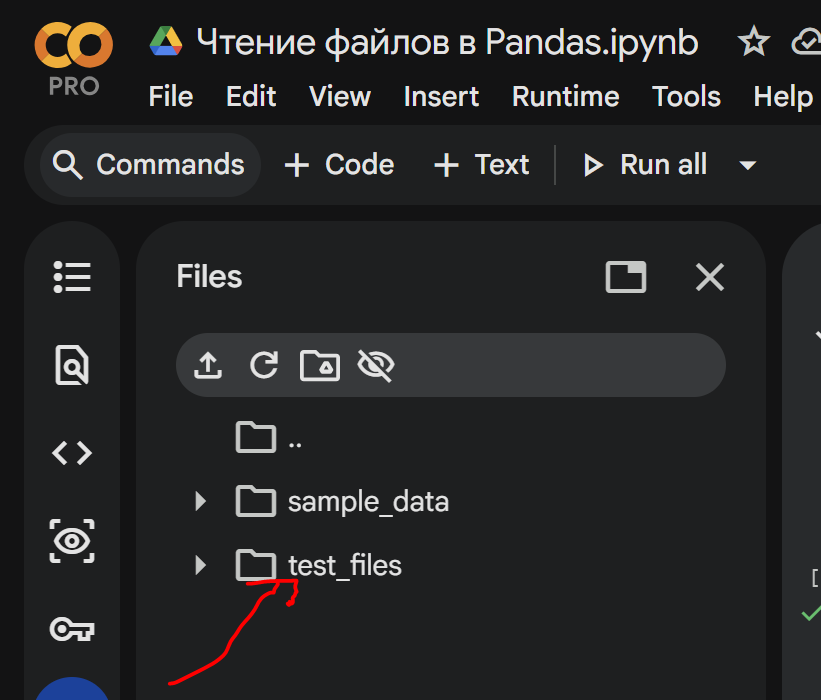

## CSV — старый добрый текстовый формат
CSV — это текст, разделённый запятыми. Основные методы: `to_csv()` для сохранения и `read_csv()` для чтения.

**Важные параметры:**
- `sep` — разделитель (запятая `,`, точка с запятой `;`, табуляция `\t`)
- `encoding` — кодировка (`utf-8`, `cp1251` для Windows)
- `index` — сохранять ли индексы (обычно `False`)
- `dtype` — словарь с типами колонок (чтобы Pandas не угадывал)

In [ ]:
# === ЗАПИСЬ ===
# Стандартный CSV
df_original.to_csv('/content/test_files/clients_utf8.csv', index=False, encoding='utf-8')

# CSV с разделителем ";" (Windows-стиль)
df_original.to_csv('/content/test_files/clients_semicolon.csv', sep=';', index=False, encoding='cp1251')

# CSV с явным указанием типов при чтении
start = time.time()
df_csv_typed = pd.read_csv(
    '/content/test_files/clients_utf8.csv',
    dtype={
        'client_id': 'int32',
        'name': 'string',
        'age': 'int8',
        'income': 'int32',
        'dti': 'float32',
        'default': 'bool'
    },
    parse_dates=['application_date']
)
csv_typed_time = time.time() - start
print(f"CSV (с типами): {csv_typed_time:.3f} сек")

# Чтение только нужных колонок
df_csv_cols = pd.read_csv('/content/test_files/clients_utf8.csv', usecols=['client_id', 'income', 'dti'])
print(f"\nТолько нужные колонки (5 строк):")
print(df_csv_cols.head())

# Windows-стиль (разделитель ";")
df_win = pd.read_csv('/content/test_files/clients_semicolon.csv', sep=';', encoding='cp1251')
print(f"\nWindows-стиль прочитан: {len(df_win)} строк")

CSV (с типами): 0.086 сек

Только нужные колонки (5 строк):
   client_id  income   dti
0       1001  304354  0.34
1       1002  201441  0.68
2       1003  489868  0.55
3       1004   78267  0.27
4       1005  174115  0.88

Windows-стиль прочитан: 50000 строк


## Excel — корпоративное наследие
Excel-файлы читаются через `pd.read_excel()` и сохраняются через `df.to_excel()`.

**Особенности:**
- Поддерживает `.xlsx` (и старые `.xls`)
- Можно указать лист через `sheet_name`
- Есть параметр `skiprows` для пропуска строк
- На больших объёмах работает медленнее CSV

In [ ]:
# Пишем в Excel
df_original.head(100).to_excel('/content/test_files/clients_small.xlsx', sheet_name='Clients', index=False)

# Читаем Excel с параметрами
df_excel = pd.read_excel(
    '/content/test_files/clients_small.xlsx',
    sheet_name='Clients',        # Имя листа
    dtype={'age': 'int8'},       # Явно указываем тип для возраста
    usecols=['client_id', 'name', 'income', 'dti']  # Только нужные колонки
)
print("Данные из Excel:")
print(df_excel.head())

# Сравнение скорости: CSV vs Excel (на 100 строках)
start = time.time()
pd.read_csv('/content/test_files/clients_utf8.csv', nrows=100)
csv_time = time.time() - start

start = time.time()
pd.read_excel('/content/test_files/clients_small.xlsx')
excel_time = time.time() - start

print(f"\nСкорость чтения 100 строк:")
print(f"CSV:   {csv_time:.4f} сек")
print(f"Excel: {excel_time:.4f} сек")
print(f"CSV быстрее в {excel_time/csv_time:.1f} раз")

Данные из Excel:
   client_id       name  income   dti
0       1001    Алексей  304354  0.34
1       1002  Екатерина  201441  0.68
2       1003      Мария  489868  0.55
3       1004     Сергей   78267  0.27
4       1005    Алексей  174115  0.88

Скорость чтения 100 строк:
CSV:   0.0051 сек
Excel: 0.0288 сек
CSV быстрее в 5.6 раз


## JSON — язык веба
JSON — основной формат обмена данными в API. Pandas читает его через `pd.read_json()` и сохраняет через `df.to_json()`.

**Важные параметры `to_json()`:**
- `orient` — структура JSON: `'records'` (список словарей), `'columns'`, `'index'`, `'values'`
- `force_ascii=False` — чтобы кириллица не превращалась в `\uXXXX`

**Особенность:** JSON — текстовый формат, поэтому файлы занимают больше места, чем бинарные форматы.

In [ ]:
# JSON в формате "records" (как ответ API), с современным форматом даты
df_original.head(100).to_json(
    '/content/test_files/clients_records.json',
    orient='records',
    force_ascii=False,  # чтобы кириллица не экранировалась
    indent=2,           # читаемый отступ
    date_format='iso'   # убираем предупреждение Pandas Warning
)

# JSON в формате "columns"
df_original.head(100).to_json(
    '/content/test_files/clients_columns.json',
    orient='columns',
    force_ascii=False,
    date_format='iso'
)


# Читаем JSON, сгенерированный в формате records
df_json = pd.read_json('/content/test_files/clients_records.json', orient='records')
print("JSON (records):")
print(df_json.head())

# Читаем колоночный JSON
df_json_col = pd.read_json('/content/test_files/clients_columns.json', orient='columns')
print("\nJSON (columns):")
print(df_json_col.head())

# Читаем JSON из Python-строки
import io
json_string = '[{"name":"Ваня","income":80000},{"name":"Оля","income":95000}]'
df_from_string = pd.read_json(io.StringIO(json_string), orient='records')
print("\nJSON из строки:")
print(df_from_string)

JSON (records):
   client_id       name  age  income   dti  default         application_date
0       1001    Алексей   43  304354  0.34    False  2024-01-01T00:00:00.000
1       1002  Екатерина   43  201441  0.68    False  2024-01-01T01:00:00.000
2       1003      Мария   49  489868  0.55    False  2024-01-01T02:00:00.000
3       1004     Сергей   26   78267  0.27    False  2024-01-01T03:00:00.000
4       1005    Алексей   59  174115  0.88    False  2024-01-01T04:00:00.000

JSON (columns):
   client_id       name  age  income   dti  default         application_date
0       1001    Алексей   43  304354  0.34    False  2024-01-01T00:00:00.000
1       1002  Екатерина   43  201441  0.68    False  2024-01-01T01:00:00.000
2       1003      Мария   49  489868  0.55    False  2024-01-01T02:00:00.000
3       1004     Сергей   26   78267  0.27    False  2024-01-01T03:00:00.000
4       1005    Алексей   59  174115  0.88    False  2024-01-01T04:00:00.000

JSON из строки:
   name  income
0  Ваня   

## Parquet — выбор профессионалов
Parquet — бинарный колоночный формат. В Pandas 3.0 он читается через `pd.read_parquet()` и сохраняется через `df.to_parquet()` с использованием PyArrow под капотом.

**Почему Parquet крут:**
- Хранит типы данных внутри — не надо гадать
- Сжимает данные (размер меньше CSV в разы)
- Читается колонками — если нужна только пара колонок, читаются только они

**Важные параметры `to_parquet()`:**
- `compression` — тип сжатия: `'snappy'` (по умолчанию), `'gzip'`, `'brotli'`, `'lz4'`, `'zstd'`
- `index` — сохранять ли индексы

_"Show yourself, show yourself, I wanna see everything you're made of." — Mastodon, Show Yourself_

In [ ]:
# Parquet со сжатием snappy (по умолчанию)
df_original.to_parquet(
    '/content/test_files/clients_snappy.parquet',
    compression='snappy',
    index=False
)

# Parquet со сжатием gzip (сильнее, но медленнее)
df_original.to_parquet(
    '/content/test_files/clients_gzip.parquet',
    compression='gzip',
    index=False
)

# Parquet со сжатием zstd (хороший баланс)
df_original.to_parquet(
    '/content/test_files/clients_zstd.parquet',
    compression='zstd',
    index=False
)


# Читаем Parquet
start = time.time()
df_parquet = pd.read_parquet('/content/test_files/clients_snappy.parquet')
parquet_time = time.time() - start
print(f"Parquet: {parquet_time:.3f} сек")
print(df_parquet.head())

# Читаем только нужные колонки
start = time.time()
df_pq_cols = pd.read_parquet('/content/test_files/clients_snappy.parquet', columns=['client_id', 'income', 'dti'])
pq_cols_time = time.time() - start
print(f"\nParquet (только 3 колонки): {pq_cols_time:.3f} сек")
print(df_pq_cols.head())

Parquet: 0.074 сек
   client_id       name  age  income   dti  default    application_date
0       1001    Алексей   43  304354  0.34    False 2024-01-01 00:00:00
1       1002  Екатерина   43  201441  0.68    False 2024-01-01 01:00:00
2       1003      Мария   49  489868  0.55    False 2024-01-01 02:00:00
3       1004     Сергей   26   78267  0.27    False 2024-01-01 03:00:00
4       1005    Алексей   59  174115  0.88    False 2024-01-01 04:00:00

Parquet (только 3 колонки): 0.007 сек
   client_id  income   dti
0       1001  304354  0.34
1       1002  201441  0.68
2       1003  489868  0.55
3       1004   78267  0.27
4       1005  174115  0.88


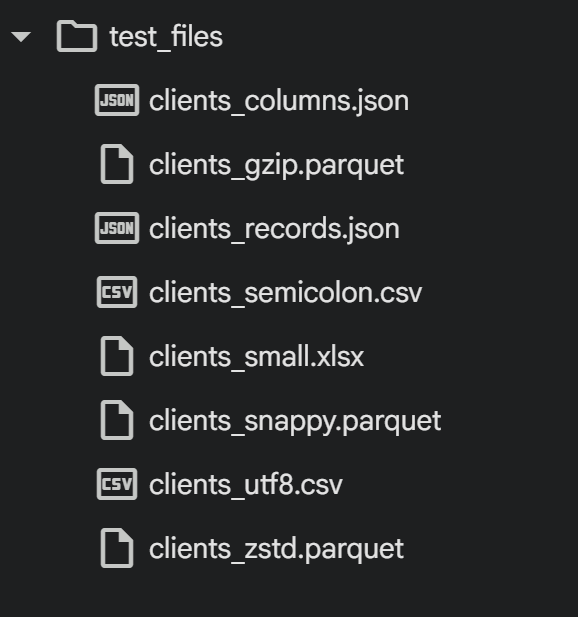

## Сравнение скорости: CSV vs Parquet
Давай проведём честный бенчмарк на 50 000 строк. Замерим время чтения и размер файлов.

In [ ]:
# === БЕНЧМАРК ===
results = []

# CSV (utf-8, с указанием типов)
start = time.time()
pd.read_csv('/content/test_files/clients_utf8.csv',
    dtype={'client_id':'int32','name':'string','age':'int8','income':'int32','dti':'float32','default':'bool'},
    parse_dates=['application_date'])
results.append(('CSV', time.time() - start, os.path.getsize('/content/test_files/clients_utf8.csv')))

# CSV (только 3 колонки)
start = time.time()
pd.read_csv('/content/test_files/clients_utf8.csv', usecols=['client_id', 'income', 'dti'])
results.append(('CSV (3 cols)', time.time() - start, os.path.getsize('/content/test_files/clients_utf8.csv')))

# Parquet snappy
start = time.time()
pd.read_parquet('/content/test_files/clients_snappy.parquet')
results.append(('Parquet snappy', time.time() - start, os.path.getsize('/content/test_files/clients_snappy.parquet')))

# Parquet gzip
start = time.time()
pd.read_parquet('/content/test_files/clients_gzip.parquet')
results.append(('Parquet gzip', time.time() - start, os.path.getsize('/content/test_files/clients_gzip.parquet')))

# Parquet zstd
start = time.time()
pd.read_parquet('/content/test_files/clients_zstd.parquet')
results.append(('Parquet zstd', time.time() - start, os.path.getsize('/content/test_files/clients_zstd.parquet')))

# Parquet (только 3 колонки)
start = time.time()
pd.read_parquet('/content/test_files/clients_snappy.parquet', columns=['client_id', 'income', 'dti'])
results.append(('Parquet (3 cols)', time.time() - start, os.path.getsize('/content/test_files/clients_snappy.parquet')))

# Вывод результатов
print(f"{'Формат':<20} {'Время (сек)':<15} {'Размер (MB)':<15} {'Скорость (MB/s)':<15}")
print("-" * 65)
for name, t, size in results:
    mb = size / (1024**2)
    speed = mb / t if t > 0 else float('inf')
    print(f"{name:<20} {t:<15.4f} {mb:<15.2f} {speed:<15.1f}")

Формат               Время (сек)     Размер (MB)     Скорость (MB/s)
-----------------------------------------------------------------
CSV                  0.1529          2.84            18.6           
CSV (3 cols)         0.0723          2.84            39.3           
Parquet snappy       0.0149          1.14            76.5           
Parquet gzip         0.0197          0.81            41.1           
Parquet zstd         0.0147          0.88            59.9           
Parquet (3 cols)     0.0089          1.14            127.6          


## Сравнение размеров файлов
Размер имеет значение! Особенно когда данных много.

In [ ]:
file_specs = {
    'CSV (utf-8)': '/content/test_files/clients_utf8.csv',
    'CSV (cp1251)': '/content/test_files/clients_semicolon.csv',
    'Excel (.xlsx)': '/content/test_files/clients_small.xlsx',
    'JSON (records)': '/content/test_files/clients_records.json',
    'JSON (columns)': '/content/test_files/clients_columns.json',
    'Parquet (snappy)': '/content/test_files/clients_snappy.parquet',
    'Parquet (gzip)': '/content/test_files/clients_gzip.parquet',
    'Parquet (zstd)': '/content/test_files/clients_zstd.parquet'
}

print(f"{'Формат':<25} {'Размер (KB)':<15} {'Размер (MB)':<15}")
print("-" * 55)
for name, path in file_specs.items():
    size_kb = os.path.getsize(path) / 1024
    size_mb = size_kb / 1024
    print(f"{name:<25} {size_kb:<15.1f} {size_mb:<15.3f}")

Формат                    Размер (KB)     Размер (MB)    
-------------------------------------------------------
CSV (utf-8)               2911.4          2.843          
CSV (cp1251)              2613.1          2.552          
Excel (.xlsx)             8.9             0.009          
JSON (records)            17.5            0.017          
JSON (columns)            10.0            0.010          
Parquet (snappy)          1164.2          1.137          
Parquet (gzip)            830.1           0.811          
Parquet (zstd)            901.8           0.881          


## Ключевые выводы

- **CSV** — универсальный формат, читается везде, но медленный и не хранит типы.
- **Excel** — для отчётов и обмена с бизнесом. На больших объёмах лучше не использовать.
- **JSON** — для API и веб-приложений. Занимает много места.
- **Parquet** — выбор для ML-пайплайнов и Big Data. Быстрый, компактный


## Что ещё умеет читать Pandas

Наша ритм-секция не ограничивается 4 форматами. Pandas 3.0 поддерживает:
- **Feather** — быстрый бинарный формат для обмена между Python и R
- **ORC** — ещё один колоночный формат (часто в Hadoop)
- **HDF5** — для огромных массивов научных данных
- **SQL** — напрямую из базы данных через `pd.read_sql()`
- **HTML** — парсинг таблиц с веб-страниц через `pd.read_html()`
- **Clipboard** — копипаст таблиц прямо из Excel/Wikipedia

В этом модуле главное — отточить четвёрку (CSV, Excel, JSON, Parquet). Остальное освоишь, когда реально надо будет, а пока лишним не стоит забивать голову.